In [72]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [73]:
df = pd.read_csv('titanic_synthetic_2000.csv')

In [74]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Person_0,male,48.600972,1,1,TCK86060,11.820252,NaN,C
1,2,1,3,Person_1,male,34.384583,1,0,TCK36673,20.680504,C141,S
2,3,0,3,Person_2,male,21.508953,3,3,TCK73471,41.240461,NaN,Q
3,4,0,3,Person_3,female,36.382659,2,2,TCK27156,44.960961,C141,C
4,5,0,3,Person_4,male,23.572736,0,1,TCK67287,NaN,C141,S


In [75]:
df.isnull().sum()

PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             200
SibSp             0
Parch             0
Ticket            0
Fare            200
Cabin          1451
Embarked          0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(0)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  2000 non-null   int64  
 1   Survived     2000 non-null   int64  
 2   Pclass       2000 non-null   int64  
 3   Name         2000 non-null   object 
 4   Sex          2000 non-null   object 
 5   Age          1800 non-null   float64
 6   SibSp        2000 non-null   int64  
 7   Parch        2000 non-null   int64  
 8   Ticket       2000 non-null   object 
 9   Fare         1800 non-null   float64
 10  Cabin        549 non-null    object 
 11  Embarked     2000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 187.6+ KB


In [78]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,2000.000000,2000.000000,2000.000000,1800.000000,2000.000000,2000.000000,1800.000000
mean,1000.500000,0.492000,2.311000,29.739282,1.928000,2.094500,49.910692
std,577.494589,0.500061,0.781399,13.906898,1.439045,1.419358,47.404717
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000
25%,500.750000,0.000000,2.000000,19.849832,1.000000,1.000000,15.021566
50%,1000.500000,0.000000,3.000000,29.866066,2.000000,2.000000,35.811352
75%,1500.250000,1.000000,3.000000,39.183911,3.000000,3.000000,70.032462
max,2000.000000,1.000000,3.000000,75.403302,4.000000,4.000000,350.000000


In [79]:
df.shape

(2000, 12)

In [80]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Person_0,male,48.600972,1,1,TCK86060,11.820252,NaN,C
1,2,1,3,Person_1,male,34.384583,1,0,TCK36673,20.680504,C141,S
2,3,0,3,Person_2,male,21.508953,3,3,TCK73471,41.240461,NaN,Q
3,4,0,3,Person_3,female,36.382659,2,2,TCK27156,44.960961,C141,C
4,5,0,3,Person_4,male,23.572736,0,1,TCK67287,NaN,C141,S


In [81]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Person_0,male,48.600972,1,1,TCK86060,11.820252,NaN,C
1,2,1,3,Person_1,male,34.384583,1,0,TCK36673,20.680504,C141,S
2,3,0,3,Person_2,male,21.508953,3,3,TCK73471,41.240461,NaN,Q
3,4,0,3,Person_3,female,36.382659,2,2,TCK27156,44.960961,C141,C
4,5,0,3,Person_4,male,23.572736,0,1,TCK67287,NaN,C141,S


OutLier Detection.................................................................

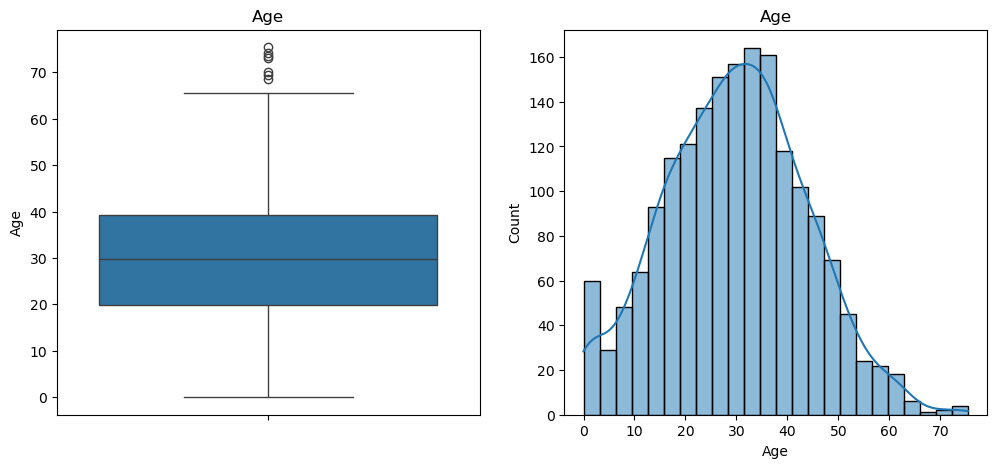

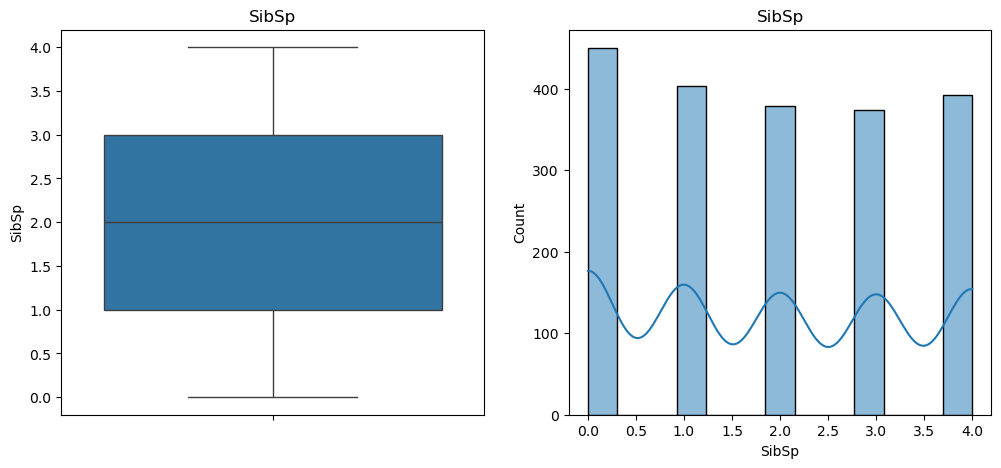

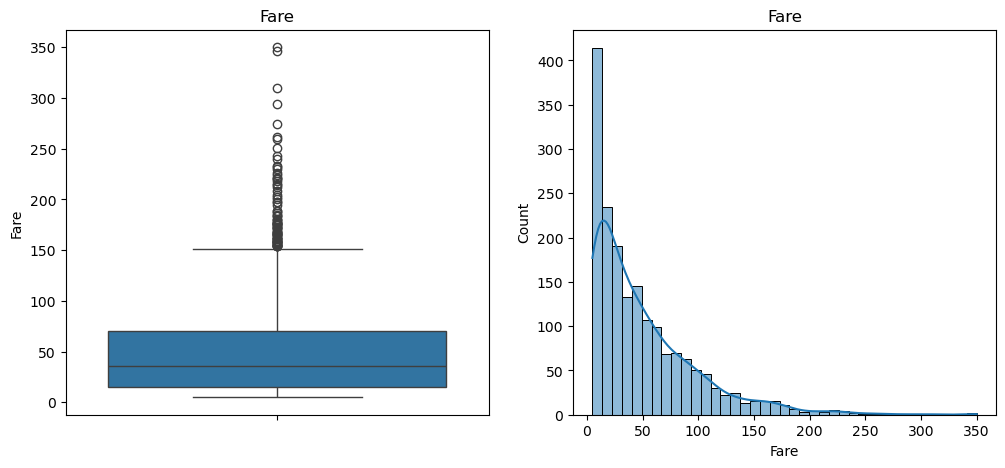

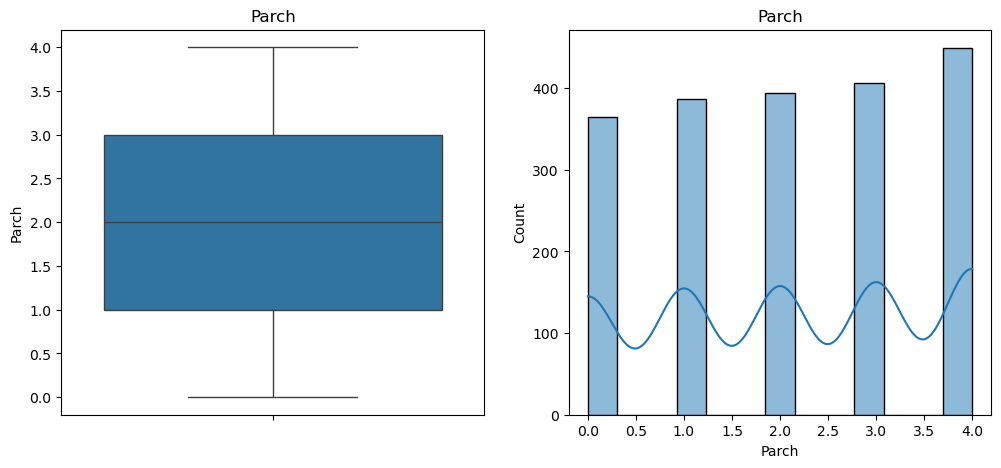

In [82]:
num_col = ['Age', 'SibSp', 'Fare', 'Parch']

for col in num_col: 
    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    sns.boxplot(df[col])
    plt.title(col)

    plt.subplot(1,2,2)
    sns.histplot(df[col], kde=True)
    plt.title(col)

In [83]:
df['Fare'].describe()

count    1800.000000
mean       49.910692
std        47.404717
min         5.000000
25%        15.021566
50%        35.811352
75%        70.032462
max       350.000000
Name: Fare, dtype: float64

In [84]:
# IQR Method 
percentile75 = df['Fare'].quantile(0.75)
percentile25 = df['Fare'].quantile(0.25)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr 

In [85]:
# find out outlies 
df[df['Fare'] > upper_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
32,33,1,2,Person_32,male,24.264388,0,3,TCK87123,221.039708,NaN,S
38,39,0,1,Person_38,male,39.977968,4,1,TCK93279,309.790939,NaN,Q
75,76,1,2,Person_75,female,56.759867,0,0,TCK31395,164.512345,NaN,S
79,80,1,3,Person_79,female,12.431083,2,1,TCK27905,176.980456,NaN,S
80,81,0,3,Person_80,male,32.585947,3,2,TCK29056,203.964264,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1837,1838,1,1,Person_1837,female,29.314490,2,1,TCK57455,261.994491,NaN,C
1845,1846,0,2,Person_1845,male,25.378737,3,4,TCK70067,161.202217,C141,S
1870,1871,0,3,Person_1870,female,48.033060,1,4,TCK45592,186.177850,NaN,S
1892,1893,0,3,Person_1892,female,40.206891,1,1,TCK24642,183.792033,NaN,C


In [86]:
df[df['Fare'] < lower_limit]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [87]:
# Capping.......................
new_df_cap = df.copy() 

new_df_cap['Fare'] = np.where(
    new_df_cap['Fare'] > upper_limit, 
    upper_limit,

    np.where(
        new_df_cap['Fare'] < lower_limit, 
        lower_limit, 
        new_df_cap['Fare']
    )
)


In [88]:
new_df_cap.shape

(2000, 12)

<Axes: ylabel='Fare'>

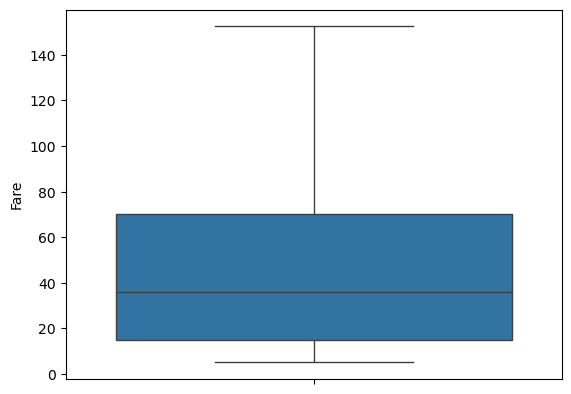

In [89]:
sns.boxplot(new_df_cap['Fare'])

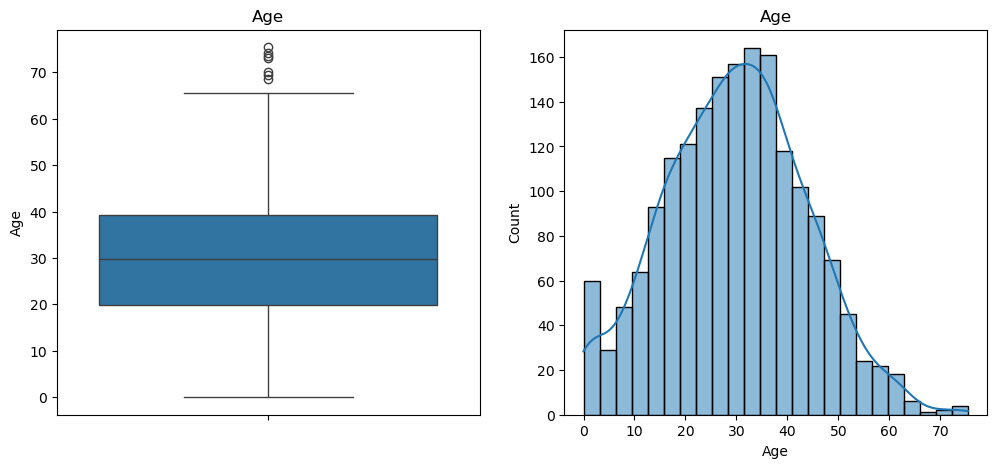

In [90]:
plt.figure(figsize=(12, 5)) 

plt.subplot(1,2,1)
sns.boxplot(new_df_cap['Age'])
plt.title('Age')

plt.subplot(1,2,2)
sns.histplot(new_df_cap['Age'], kde=True)
plt.title('Age')

plt.show()

In [91]:
# z-Score Method..........................
print('Highest allowed', new_df_cap['Age'].mean() + 3*new_df_cap['Age'].std())
print('Lowest allowed', new_df_cap['Age'].mean() - 3*new_df_cap['Age'].std())

Highest allowed 71.45997527462184
Lowest allowed -11.981410316040499


In [92]:
new_df_cap[(new_df_cap['Age'] > 71.45) | (new_df_cap['Age'] < -11.98)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
558,559,1,3,Person_558,male,75.403302,0,4,TCK32787,6.961404,NaN,C
824,825,1,3,Person_824,female,74.128794,0,4,TCK93301,NaN,NaN,S
1712,1713,0,2,Person_1712,male,73.076045,4,4,TCK62044,152.548805,NaN,S
1839,1840,0,2,Person_1839,male,73.580743,1,4,TCK62433,12.156904,NaN,C


In [95]:
# capping 
upperlimit = new_df_cap['Age'].mean() + 3*new_df_cap['Age'].std()
lowerlimit = new_df_cap['Age'].mean() - 3*new_df_cap['Age'].std()

new_df_cap['Age'] = np.where(
    new_df_cap['Age'] > upperlimit, 
    upperlimit, 

    np.where(
        new_df_cap['Age'] < lowerlimit, 
        lowerlimit, 
        new_df_cap['Age']
    )
)

In [96]:
new_df_cap.shape

(2000, 12)

Text(0.5, 1.0, 'Age')

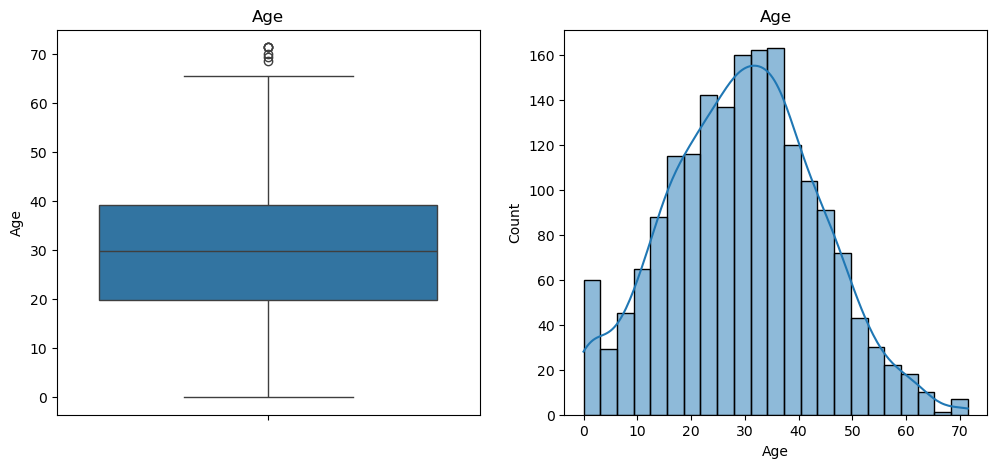

In [97]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.boxplot(new_df_cap['Age'])
plt.title('Age')

plt.subplot(1,2,2)
sns.histplot(new_df_cap['Age'], kde=True)
plt.title('Age')

In [98]:
new_df_cap.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,Person_0,male,48.600972,1,1,TCK86060,11.820252,NaN,C
1,2,1,3,Person_1,male,34.384583,1,0,TCK36673,20.680504,C141,S
2,3,0,3,Person_2,male,21.508953,3,3,TCK73471,41.240461,NaN,Q
3,4,0,3,Person_3,female,36.382659,2,2,TCK27156,44.960961,C141,C
4,5,0,3,Person_4,male,23.572736,0,1,TCK67287,NaN,C141,S


In [99]:
from sklearn.model_selection import train_test_split 

In [100]:
x = new_df_cap.drop('Survived', axis=1)
y = new_df_cap['Survived']

In [101]:
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.3, 
    random_state=12
)

In [102]:
x_train.shape, x_test.shape

((1400, 11), (600, 11))